## Logistics Regression

    This is classification based algorithm that is used to predict target classes

    Business Objective: Build a model that can predict species of Iris flower on basis of flower petal length/width and sepal length/width

## Step 1 : Data Gathering

In [1]:
import pandas as pd
path = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/iris.csv"
df = pd.read_csv(path)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step2: Perform basic data quality checks

In [2]:
df.shape

(150, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## Separate X and Y features

Predict Species : Y

In [8]:
X = df.drop(columns='species')
Y = df[['species']]
print("X Records")
display(X.head())
print("Y Records")
display(Y.head())

X Records


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Y Records


,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


## Step4: SPlit the data into training and testing

    training: 80% and testing: 20%

In [9]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(X,Y, train_size=0.8, random_state=21)
print("X Training and Testing :", xtrain.shape,xtest.shape)
print("Y Training and Testing :", ytrain.shape,ytest.shape)

X Training and Testing : (119, 4) (30, 4)
Y Training and Testing : (119, 1) (30, 1)


## Data Processing: Data Cleaning

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

num_pipe = make_pipeline(SimpleImputer(strategy='median')).set_output(transform="pandas")
num_pipe

,steps,"[('simpleimputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [11]:
# fit it on training data
num_pipe.fit(xtrain)

,steps,"[('simpleimputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [12]:
# transform it on testing as well as training data
xtrain_pre = num_pipe.transform(xtrain)
xtest_pre = num_pipe.transform(xtest)

xtrain_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
41,4.5,2.3,1.3,0.3
130,7.4,2.8,6.1,1.9
70,5.9,3.2,4.8,1.8
46,5.1,3.8,1.6,0.2
125,7.2,3.2,6.0,1.8


In [13]:
xtest_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
92,5.8,2.6,4.0,1.2
44,5.1,3.8,1.9,0.4
7,5.0,3.4,1.5,0.2
21,5.1,3.7,1.5,0.4
95,5.7,3.0,4.2,1.2


## Model Building: Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xtrain_pre,ytrain)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# training scores(accuracy)
model.score(xtrain_pre,ytrain)

0.9831932773109243

In [16]:
# testing scores(accuracy)
model.score(xtest_pre,ytest)

0.9333333333333333

## Training score as well testing scores are above 80%. We can consider this model. But for further evaluation,let's check for performance metrics

    precision
    recall
    f1_score
    accuracy

In [17]:
ytest_preds = model.predict(xtest_pre)
ytest_preds[:5]

array(['versicolor', 'setosa', 'setosa', 'setosa', 'versicolor'],
      dtype=object)

In [18]:
ytest.head()

,species
92,versicolor
44,setosa
7,setosa
21,setosa
95,versicolor


In [19]:
from sklearn.metrics import f1_score

f1_score_data = f1_score(ytest,ytest_preds,average='macro')
f1_score_data 

0.9280303030303031

## Observe Confusion matrix and Classification Report

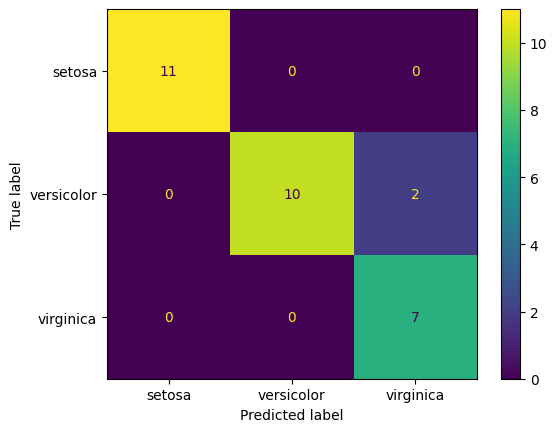

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(model, xtest_pre,ytest)


**Observation :-**

    Setosa: 11 samples were correctly predicted as Setosa. No misclassification occurred.
    Versicolor: 10 samples were correctly predicted, while 2 were incorrectly classified as Virginica.
    Virginica: 7 samples were correctly predicted with no misclassification.

In [22]:
print(classification_report(ytest,ytest_preds))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.83      0.91        12
   virginica       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30



### Imbalanced Data: Classification

    Target feature

    Datapoints:
    Class A
    Class B
    df['species'].value_counts()

In [23]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

<Axes: xlabel='species'>

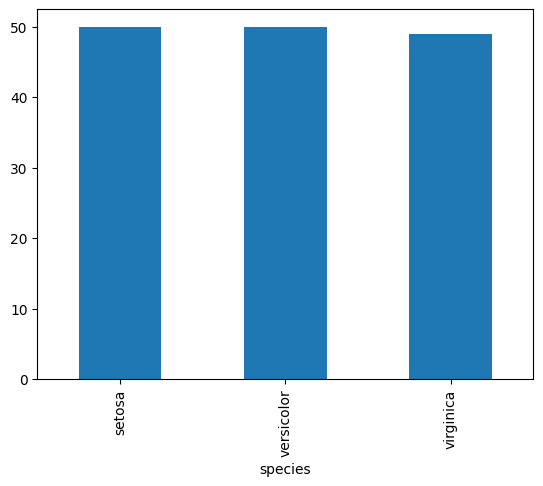

In [24]:
df['species'].value_counts().plot(kind='bar')

### Save the model as well as pipeline

In [25]:
import joblib
joblib.dump(model,"IrisPredictionModel.joblib")
joblib.dump(num_pipe,"pipeline_cleaning.joblib")

['pipeline_cleaning.joblib']

## Picking up sample data for out of sample predictions

In [27]:
xnew = pd.read_csv(r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/iris_sample.csv")
xnew.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.5,2.5,4.0,1.3
1,6.9,3.1,5.1,2.3
2,5.1,2.5,3.0,1.1
3,4.4,2.9,NaN,0.2
4,5.9,3.0,5.1,1.8


In [28]:
pipeline_loaded = joblib.load("pipeline_cleaning.joblib")
xnew_pre = pipeline_loaded.transform(xnew)
xnew_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.5,2.5,4.0,1.3
1,6.9,3.1,5.1,2.3
2,5.1,2.5,3.0,1.1
3,4.4,2.9,4.5,0.2
4,5.9,3.0,5.1,1.8


In [29]:
mdoel_loaded = joblib.load("IrisPredictionModel.joblib")
Species_Prediction = mdoel_loaded.predict(xnew_pre)
Species_Prediction[:5]


array(['versicolor', 'virginica', 'versicolor', 'versicolor', 'virginica'],
      dtype=object)

In [30]:
xnew.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.5,2.5,4.0,1.3
1,6.9,3.1,5.1,2.3
2,5.1,2.5,3.0,1.1
3,4.4,2.9,NaN,0.2
4,5.9,3.0,5.1,1.8


In [31]:
xnew["Predicted_Species"] = Species_Prediction
xnew.head()


,sepal_length,sepal_width,petal_length,petal_width,Predicted_Species
0,5.5,2.5,4.0,1.3,versicolor
1,6.9,3.1,5.1,2.3,virginica
2,5.1,2.5,3.0,1.1,versicolor
3,4.4,2.9,NaN,0.2,versicolor
4,5.9,3.0,5.1,1.8,virginica


In [32]:
xnew.to_csv("IrisSpeciesPredictedResults.csv",index=False)